# Notebook 14 — Tier 3: GraFITi (imv_start)

## Objective

Tier 3 (GraFITi) trained and evaluated on the **imv_start** windows from Notebook 11.

Same model and procedure as Notebook 10. The differences are only in the inputs: windows are placed forward from ventilation start (deployment-realistic), the triplet time column is `hours_since_imv_start`, and window origins vary per patient. Tier 1 and Tier 2 numbers come from Notebooks 12 and 13. All outputs use an `_imvstart` suffix so they sit beside the original Tier 3 results.

Includes the multi-seed check and the four publication comparison figures.

### 1. Mount Google Drive and check the input files

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/ventilator_weaning'

COHORT_DIR = f'{BASE}/cohort'
PREPROCESSING_DIR = f'{BASE}/preprocessing'
WINDOWS_DIR = f'{BASE}/windows'
RESULTS_DIR = f'{BASE}/results'
FIGURES_DIR = f'{BASE}/figures'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

required_files = {
    'triplets': f'{WINDOWS_DIR}/windows_tier3_triplets_imvstart.parquet',
    'grid': f'{WINDOWS_DIR}/windows_tier12_grid_imvstart.npz',
    'metadata': f'{WINDOWS_DIR}/windows_metadata_imvstart.json',
}

missing = []

print("Checking input files...\n")

for name, path in required_files.items():
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"FOUND    {name:10s} {size_mb:8.2f} MB   {os.path.basename(path)}")
    else:
        missing.append(path)
        print(f"MISSING  {name:10s}            {os.path.basename(path)}")

print()

if missing:
    raise FileNotFoundError(
        f"Missing {len(missing)} required file(s). "
        f"Please run Notebook 11 first.\n{missing}"
    )

print("All required files found.")
print(f"Results directory : {RESULTS_DIR}")
print(f"Figures directory : {FIGURES_DIR}")

Mounted at /content/drive
Checking input files...

FOUND    triplets      12.44 MB   windows_tier3_triplets_imvstart.parquet
FOUND    grid          11.09 MB   windows_tier12_grid_imvstart.npz
FOUND    metadata       0.00 MB   windows_metadata_imvstart.json

All required files found.
Results directory : /content/drive/MyDrive/ventilator_weaning/results
Figures directory : /content/drive/MyDrive/ventilator_weaning/figures


### 2. Load the input files and inspect their structure

In [2]:
import json
import numpy as np
import pandas as pd

# Load metadata
with open(required_files['metadata'], 'r') as f:
    metadata = json.load(f)

print("Metadata")
print("-" * 60)

for key, value in metadata.items():
    if isinstance(value, (str, int, float, bool)):
        print(f"{key}: {value}")
    elif isinstance(value, list):
        print(f"{key}: List ({len(value)} items)")
    elif isinstance(value, dict):
        print(f"{key}: Dictionary ({len(value)} keys)")
    else:
        print(f"{key}: {type(value)}")

# Load window arrays
grid = np.load(required_files['grid'], allow_pickle=True)

print("\nGrid arrays")
print("-" * 60)

for key in grid.files:
    arr = grid[key]
    print(f"{key:20s} Shape: {arr.shape}  Type: {arr.dtype}")

# Load triplet data
triplets = pd.read_parquet(required_files['triplets'])

print("\nTriplets")
print("-" * 60)
print(f"Rows    : {len(triplets):,}")
print(f"Columns : {list(triplets.columns)}")

print("\nFirst five rows")
print(triplets.head().to_string(index=False))

print("\nData types")
print(triplets.dtypes.to_string())

Metadata
------------------------------------------------------------
anchor: imv_start
context_hours: 48
warmup_hours: 48
stride_hours: 6
max_windows_per_visit: 8
horizons: List (3 items)
valid_origins: List (208 items)
features: List (13 items)
n_windows: 13017
n_visits: 1912
split_counts: Dictionary (3 keys)
units_note: paco2 and pao2 are in kPa (AmsterdamUMCdb convention)
scaler_stats: Dictionary (13 keys)
random_state: 42

Grid arrays
------------------------------------------------------------
X_context            Shape: (13017, 48, 13)  Type: float64
X_context_mask       Shape: (13017, 48, 13)  Type: float64
y_target             Shape: (13017, 3, 13)  Type: float64
y_target_mask        Shape: (13017, 3, 13)  Type: float64
window_ids           Shape: (13017,)  Type: <U11
visit_ids            Shape: (13017,)  Type: int64
split                Shape: (13017,)  Type: <U5

Triplets
------------------------------------------------------------
Rows    : 4,124,550
Columns : ['visit_occur

The metadata confirms the window settings, cohort size, features, and train/validation/test split used throughout the study.

### 3. Read the saved split and inspect the window definitions

In [3]:
split_labels = np.array(grid["split"]).ravel()
window_ids = np.array(grid["window_ids"]).ravel()
visit_ids = np.array(grid["visit_ids"]).ravel()

print("Dataset split")
print("-" * 60)

for split in ["train", "val", "test"]:
    mask = split_labels == split
    print(
        f"{split:6s} "
        f"{mask.sum():6,} windows   "
        f"{len(np.unique(visit_ids[mask])):5,} visits"
    )

print(
    f"{'total':6s} "
    f"{len(window_ids):6,} windows   "
    f"{len(np.unique(visit_ids)):5,} visits\n"
)

visits_by_split = {
    split: set(visit_ids[split_labels == split])
    for split in ["train", "val", "test"]
}

if (
    visits_by_split["train"] & visits_by_split["val"]
    or visits_by_split["train"] & visits_by_split["test"]
    or visits_by_split["val"] & visits_by_split["test"]
):
    raise ValueError("Patient-level split contains overlapping visits.")

print("Patient-level split verified.")

grid_map = {
    int(visit_ids[i]): str(split_labels[i])
    for i in range(len(visit_ids))
}

triplet_map = (
    triplets[["visit_occurrence_id", "split"]]
    .drop_duplicates()
    .set_index("visit_occurrence_id")["split"]
    .to_dict()
)

disagreements = [
    visit
    for visit, split in grid_map.items()
    if visit in triplet_map and triplet_map[visit] != split
]

print(f"Split mismatches: {len(disagreements)}")

if disagreements:
    raise ValueError("Split labels do not match between the grid and triplet files.")

test_windows = int((split_labels == "test").sum())
test_visits = len(visits_by_split["test"])
print(f"Test set: {test_visits} visits, {test_windows} windows.\n")

print("Window settings")
print("-" * 60)
print(f"Horizons        : {metadata['horizons']}")
print(f"Valid origins   : {metadata['valid_origins']}")
print(f"Context hours   : {metadata['context_hours']}")
print(f"Warm-up hours   : {metadata['warmup_hours']}")
print(f"Stride hours    : {metadata['stride_hours']}")
print(f"Max win / visit : {metadata['max_windows_per_visit']}")
print(f"Features        : {len(metadata['features'])}")
print(f"Split counts    : {metadata['split_counts']}")

print("\nExample window IDs")
print("-" * 60)

for i in range(8):
    print(f"{window_ids[i]}   Visit {visit_ids[i]}")

print(f"\nUnique windows : {len(np.unique(window_ids)):,}")
print(f"Average windows per visit : {len(window_ids) / len(np.unique(visit_ids)):.2f}")

Dataset split
------------------------------------------------------------
train   9,079 windows   1,338 visits
val     1,979 windows     287 visits
test    1,959 windows     287 visits
total  13,017 windows   1,912 visits

Patient-level split verified.
Split mismatches: 0
Test set: 287 visits, 1959 windows.

Window settings
------------------------------------------------------------
Horizons        : [1, 4, 8]
Valid origins   : [48, 54, 60, 66, 72, 78, 84, 90, 96, 102, 108, 114, 120, 126, 132, 138, 144, 150, 156, 162, 168, 174, 180, 186, 192, 198, 204, 210, 216, 222, 228, 234, 240, 246, 252, 258, 264, 270, 276, 282, 288, 294, 300, 306, 312, 318, 324, 330, 336, 342, 348, 354, 360, 366, 372, 378, 384, 390, 396, 402, 408, 414, 420, 426, 432, 438, 444, 450, 456, 462, 468, 474, 480, 486, 492, 498, 504, 510, 516, 522, 528, 534, 540, 546, 552, 558, 564, 570, 576, 582, 588, 594, 600, 606, 612, 618, 624, 630, 636, 642, 648, 654, 660, 666, 672, 678, 684, 690, 696, 702, 708, 714, 720, 726, 732,

### 4. Build the window table

In [4]:
import re

# Parse "<visit>_t<origin>" window IDs and verify them against visit_ids / metadata
pattern = re.compile(r"^(\d+)_t(-?\d+)$")

parsed_visits = []
parsed_origins = []
invalid_ids = []

for wid in window_ids:
    match = pattern.match(str(wid))
    if match:
        parsed_visits.append(int(match.group(1)))
        parsed_origins.append(int(match.group(2)))
    else:
        invalid_ids.append(str(wid))

if invalid_ids:
    raise ValueError(
        f"{len(invalid_ids)} invalid window IDs found. "
        f"Examples: {invalid_ids[:5]}"
    )

parsed_visits = np.array(parsed_visits)
parsed_origins = np.array(parsed_origins)

if np.any(parsed_visits != visit_ids):
    raise ValueError("Visit IDs extracted from window IDs do not match visit_ids.")

if not set(parsed_origins).issubset(set(metadata["valid_origins"])):
    raise ValueError("Some window origins are not listed in the metadata.")

print("Window IDs verified.\n")

windows_table = pd.DataFrame({
    "row_index": np.arange(len(window_ids)),
    "window_id": window_ids,
    "visit_id": parsed_visits,
    "origin": parsed_origins,
    "split": split_labels,
})


Window IDs verified.



### 5. Set up the feature binning

In [5]:
CONTEXT_HOURS = metadata["context_hours"]
FEATURES = metadata["features"]

# Column position of each feature, used when packing the arrays.
feature_position = {feature: i for i, feature in enumerate(FEATURES)}

print(f"Context window: {CONTEXT_HOURS} hours across {len(FEATURES)} features.")

Context window: 48 hours across 13 features.


### 6. Drop empty measurements

A few triplet rows carry no value. They are removed so that every measurement the model
reads is real, and the per-visit lookup is rebuilt from the cleaned rows.

In [6]:
# Keep only rows that actually carry a value.
triplets_clean = triplets[triplets['value_as_number'].notna()].copy()

print(f'Rows before : {len(triplets):,}')
print(f'Rows after  : {len(triplets_clean):,}')
print(f'Removed     : {len(triplets) - len(triplets_clean):,}')
print()

# Rebuild the per-visit lookup from the cleaned rows.
triplets_by_visit = {}
for visit, group in triplets_clean.groupby('visit_occurrence_id'):
    triplets_by_visit[int(visit)] = group[
        ['feature_name', 'hours_since_imv_start', 'value_as_number']
    ].to_numpy()

print(f'Rebuilt lookup for {len(triplets_by_visit):,} visits.')

Rows before : 4,124,550
Rows after  : 4,119,418
Removed     : 5,132

Rebuilt lookup for 1,912 visits.


### 7. Load GraFITi

Clone the official implementation from the GraFITi paper (Yalavarthi et al., AAAI 2024)
and check the imports, the GPU and the random seed.

In [7]:
import sys

GRAFITI_DIR = '/content/GraFITi'

if not os.path.exists(GRAFITI_DIR):
    !git clone -q https://github.com/yalavarthivk/GraFITi.git {GRAFITI_DIR}

# The repo root holds an old __init__.py, so the folder must not be called "grafiti".
if GRAFITI_DIR not in sys.path:
    sys.path.insert(0, GRAFITI_DIR)

print("GraFITi source:", GRAFITI_DIR)

GraFITi source: /content/GraFITi


In [8]:
import random
import time
import copy

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

from grafiti.grafiti import GraFITi

SEED = metadata["random_state"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"torch  : {torch.__version__}")
print(f"device : {device}")
if device.type == "cuda":
    print(f"gpu    : {torch.cuda.get_device_name(0)}")
print(f"seed   : {SEED}")

torch  : 2.11.0+cu128
device : cuda
gpu    : Tesla T4
seed   : 42


In [9]:
# AI-assisted: the smoke-test batch layout, generated with Claude Opus 4.8 and verified by the author.
# GraFITi puts the context times and the target times on one timeline.
# Context rows carry x_vals and x_mask, target rows carry y_mask.

n_features = len(FEATURES)
check_model = GraFITi(input_dim=n_features, attn_head=2, latent_dim=64,
                      n_layers=2, device=device).to(device)

b, n_ctx, n_tgt = 2, 20, len(metadata["horizons"])

ctx_time = torch.sort(torch.rand(b, n_ctx) * CONTEXT_HOURS, dim=1).values
ctx_vals = torch.randn(b, n_ctx, n_features)
ctx_mask = (torch.rand(b, n_ctx, n_features) > 0.6).float()

tgt_time = torch.tensor(metadata["horizons"], dtype=torch.float32).repeat(b, 1)
tgt_mask = torch.ones(b, n_tgt, n_features)

x_time = torch.cat([ctx_time, tgt_time], dim=1).to(device)
x_vals = torch.cat([ctx_vals * ctx_mask, torch.zeros(b, n_tgt, n_features)], dim=1).to(device)
x_mask = torch.cat([ctx_mask, torch.zeros(b, n_tgt, n_features)], dim=1).to(device)
y_mask = torch.cat([torch.zeros(b, n_ctx, n_features), tgt_mask], dim=1).to(device)

with torch.no_grad():
    out = check_model(x_time, x_vals, x_mask, y_mask)

print("output shape:", tuple(out.shape))
print("expected    :", (b, n_ctx + n_tgt, n_features))

del check_model

output shape: (2, 23, 13)
expected    : (2, 23, 13)


**Interpretation**

The model loads and runs a forward pass on the GPU. The output covers the whole
timeline, and only the target positions are scored later.

### 8. Scaling, targets and the persistence baseline

The grid arrays from Notebook 11 are stored in scaled units. The same scaler is reused
here, so Tier 3 trains in the same space as Tier 1 and is reported in the same clinical
units. The targets and the baseline are taken from the grid file so that all three tiers
are scored on identical values.

In [10]:
feature_names = list(metadata["features"])
N_VARIATES = len(feature_names)

HORIZONS = metadata["horizons"]
N_HORIZONS = len(HORIZONS)

scaler_mean = np.array([metadata["scaler_stats"][f]["mean"] for f in feature_names])
scaler_std = np.array([metadata["scaler_stats"][f]["std"] for f in feature_names])

context = grid["X_context"]
context_mask = grid["X_context_mask"]
targets = grid["y_target"]
target_mask = grid["y_target_mask"]

# Back to native clinical units
context_native = context * scaler_std + scaler_mean
targets_native = targets * scaler_std + scaler_mean

train_mask = split_labels == "train"
val_mask = split_labels == "val"
test_mask = split_labels == "test"

print("Feature order:")
print(feature_names)
print(f"\nHorizons     : {HORIZONS}")
print(f"Context      : {CONTEXT_HOURS} hours")
print(f"Train / val / test windows: {train_mask.sum()} / {val_mask.sum()} / {test_mask.sum()}")

Feature order:
['diastolic_bp', 'fio2', 'heart_rate', 'lactate', 'mean_bp', 'paco2', 'pao2', 'peep', 'ph', 'respiratory_rate', 'spo2', 'systolic_bp', 'tidal_volume']

Horizons     : [1, 4, 8]
Context      : 48 hours
Train / val / test windows: 9079 / 1979 / 1959


In [11]:
# AI-assisted: finding the last observed value per window, generated with Claude Opus 4.8 and verified by the author.
def build_persistence(ctx_native, ctx_mask, fallback):
    n = ctx_native.shape[0]
    out = np.zeros((n, N_HORIZONS, N_VARIATES))

    for i in range(n):
        for v in range(N_VARIATES):
            observed = np.where(ctx_mask[i, :, v] == 1)[0]
            if len(observed) > 0:
                last_val = ctx_native[i, observed[-1], v]
            else:
                last_val = fallback[v]
            out[i, :, v] = last_val

    return out


test_persist = build_persistence(
    context_native[test_mask], context_mask[test_mask], scaler_mean
)

print(f"Test baseline shape: {test_persist.shape}")

Test baseline shape: (1959, 3, 13)


In [12]:
def masked_mae_native(pred, true, mask):
    return (np.abs(pred - true) * mask).sum() / (mask.sum() + 1e-8)


def masked_rmse_native(pred, true, mask):
    sq = ((pred - true) ** 2) * mask
    return np.sqrt(sq.sum() / (mask.sum() + 1e-8))


def overall_scores(pred, true, mask, persist):
    mae = masked_mae_native(pred, true, mask)
    persist_mae = masked_mae_native(persist, true, mask)
    return mae, mae / (persist_mae + 1e-8)


print("Metric functions ready.")

Metric functions ready.


**Interpretation**

The metric functions and the persistence baseline are the same as in Notebook 12 and
Notebook 13. Only the observed target cells count towards any score, so the models are
never graded against a filled value.

### 9. Building the GraFITi samples

Each window is turned into a list of observation times together with the values and the
mask at those times. The window covers `[origin - 48, origin)` (left-closed, right-open),
so times are measured in hours from the start of the window: the context sits in `[0, 48)`
and the targets sit at 49, 52 and 56 hours.

In [13]:
# AI-assisted: collapsing repeated measurements per timestamp, generated with Claude Opus 4.8 and verified by the author.
def build_context(visit_id, origin):
    rows = triplets_by_visit[visit_id]
    times = rows[:, 1].astype(float)

    start = origin - CONTEXT_HOURS
    keep = (times >= start) & (times < origin)

    rows = rows[keep]
    times = times[keep] - start

    stamps = np.unique(times)
    slot = {t: i for i, t in enumerate(stamps)}

    total = np.zeros((len(stamps), N_VARIATES), dtype=np.float32)
    count = np.zeros((len(stamps), N_VARIATES), dtype=np.float32)

    for k in range(len(rows)):
        i = slot[times[k]]
        j = feature_position[rows[k, 0]]
        total[i, j] += (float(rows[k, 2]) - scaler_mean[j]) / scaler_std[j]
        count[i, j] += 1.0

    mask = (count > 0).astype(np.float32)
    values = np.divide(total, count, out=np.zeros_like(total), where=count > 0)

    return stamps.astype(np.float32), values, mask

In [14]:
samples = []

for row in windows_table.itertuples():
    samples.append(build_context(int(row.visit_id), int(row.origin)))

    if len(samples) % 2000 == 0:
        print(f"{len(samples):,} windows built")

print(f"\nTotal windows built: {len(samples):,}")

lengths = np.array([len(s[0]) for s in samples])
observed = np.array([int(s[2].sum()) for s in samples])

print(f"Timestamps per window : min {lengths.min()}, median {int(np.median(lengths))}, max {lengths.max()}")
print(f"Observations per window: min {observed.min()}, median {int(np.median(observed))}, max {observed.max()}")

2,000 windows built
4,000 windows built
6,000 windows built
8,000 windows built
10,000 windows built
12,000 windows built

Total windows built: 13,017
Timestamps per window : min 30, median 63, max 107
Observations per window: min 132, median 452, max 612


**Interpretation**

Every window now holds only the measurements that were actually recorded, at the times
they were recorded. Nothing is forward filled and no hourly grid is imposed, which is
the difference this tier is meant to test.

### 10. Dataset and DataLoader

Windows have different numbers of timestamps, so the batch is padded to the longest
window in that batch. Padded rows carry a mask of zero and are ignored by the model.

In [15]:
TARGET_TIMES = np.array([CONTEXT_HOURS + h for h in HORIZONS], dtype=np.float32)


class GrafitiWindows(Dataset):
    def __init__(self, indices):
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, k):
        i = self.indices[k]
        stamps, values, mask = samples[i]
        return stamps, values, mask, targets[i], target_mask[i]

In [16]:
# AI-assisted: padding variable-length windows into one batch, generated with Claude Opus 4.8 and verified by the author.
def collate_windows(batch):
    n_max = max(len(item[0]) for item in batch)
    n_all = n_max + N_HORIZONS
    b = len(batch)

    x_time = np.zeros((b, n_all), dtype=np.float32)
    x_vals = np.zeros((b, n_all, N_VARIATES), dtype=np.float32)
    x_mask = np.zeros((b, n_all, N_VARIATES), dtype=np.float32)
    y_vals = np.zeros((b, n_all, N_VARIATES), dtype=np.float32)
    y_mask = np.zeros((b, n_all, N_VARIATES), dtype=np.float32)

    for i, (stamps, values, mask, tgt, tgt_mask) in enumerate(batch):
        n = len(stamps)
        x_time[i, :n] = stamps
        x_vals[i, :n] = values
        x_mask[i, :n] = mask

        x_time[i, n_max:] = TARGET_TIMES
        y_vals[i, n_max:] = tgt
        y_mask[i, n_max:] = tgt_mask

    return (
        torch.from_numpy(x_time),
        torch.from_numpy(x_vals),
        torch.from_numpy(x_mask),
        torch.from_numpy(y_vals),
        torch.from_numpy(y_mask),
        n_max,
    )

In [17]:
BATCH_SIZE = 32

train_idx = np.where(train_mask)[0]
val_idx = np.where(val_mask)[0]
test_idx = np.where(test_mask)[0]

train_loader = DataLoader(GrafitiWindows(train_idx), batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=collate_windows)
val_loader = DataLoader(GrafitiWindows(val_idx), batch_size=BATCH_SIZE,
                        shuffle=False, collate_fn=collate_windows)
test_loader = DataLoader(GrafitiWindows(test_idx), batch_size=BATCH_SIZE,
                         shuffle=False, collate_fn=collate_windows)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

x_time, x_vals, x_mask, y_vals, y_mask, n_ctx = next(iter(train_loader))

print(f"\nTimeline length in this batch: {x_time.shape[1]} ({n_ctx} context + {N_HORIZONS} targets)")
print(f"Values shape: {tuple(x_vals.shape)}")

Train batches: 284
Val batches:   62
Test batches:  62

Timeline length in this batch: 85 (82 context + 3 targets)
Values shape: (32, 85, 13)


**Interpretation**

The loaders keep the patient split from Notebook 11 untouched. The test loader is not
shuffled, so its predictions line up row by row with the grid arrays used by the other
two tiers.

### 11. The model

GraFITi is built from the official implementation. Only the settings that matter are
exposed here; the rest are left at the values used in the paper.

In [18]:
ATTN_HEAD = 2
LATENT_DIM = 64
N_LAYERS = 2
LEARNING_RATE = 1e-3
N_EPOCHS = 30
EARLY_STOP_PATIENCE = 10

model = GraFITi(
    input_dim=N_VARIATES,
    attn_head=ATTN_HEAD,
    latent_dim=LATENT_DIM,
    n_layers=N_LAYERS,
    device=device,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Latent dim : {LATENT_DIM}")
print(f"Layers     : {N_LAYERS}")
print(f"Attn heads : {ATTN_HEAD}")
print(f"Parameters : {n_params:,}")

Latent dim : 64
Layers     : 2
Attn heads : 2
Parameters : 125,441


### 12. Loss function

The official GraFITi code trains on masked mean squared error. Masked mean absolute
error is used here instead so that the training objective matches Notebook 12 and the
reported metric. Only observed target cells contribute.

In [19]:
def masked_mae_loss(predictions, targets, mask):
    abs_error = torch.abs(predictions - targets) * mask
    return abs_error.sum() / (mask.sum() + 1e-8)

### 13. Training

The loop follows Notebook 12: one pass over the training windows, one over the
validation windows, keep the best state and stop early if validation stops improving.

In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def run_epoch(loader, training):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_observed = 0.0

    for x_time, x_vals, x_mask, y_vals, y_mask, n_ctx in loader:
        x_time = x_time.to(device)
        x_vals = x_vals.to(device)
        x_mask = x_mask.to(device)
        y_vals = y_vals.to(device)
        y_mask = y_mask.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            predictions = model(x_time, x_vals, x_mask, y_mask)
            loss = masked_mae_loss(predictions, y_vals, y_mask)

        if training:
            loss.backward()
            optimizer.step()

        n_observed = y_mask.sum().item()
        total_loss += loss.item() * n_observed
        total_observed += n_observed

    return total_loss / (total_observed + 1e-8)

In [21]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

start_time = time.time()

for epoch in range(1, N_EPOCHS + 1):

    train_loss = run_epoch(train_loader, training=True)
    val_loss = run_epoch(val_loader, training=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        marker = " <-- best"
    else:
        epochs_without_improvement += 1
        marker = ""

    print(f"Epoch {epoch:3d} | Train MAE: {train_loss:.4f} | Val MAE: {val_loss:.4f}{marker}")

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} "
              f"(no improvement for {EARLY_STOP_PATIENCE} epochs).")
        break

elapsed = time.time() - start_time

model.load_state_dict(best_model_state)
torch.save(best_model_state, f"{RESULTS_DIR}/tier3_grafiti_best_imvstart.pt")

print(f"\nTraining finished in {elapsed:.1f} seconds ({elapsed / 60:.1f} minutes)")
print(f"Best validation MAE: {best_val_loss:.4f}")
print(f"Checkpoint saved to {RESULTS_DIR}/tier3_grafiti_best_imvstart.pt")

Epoch   1 | Train MAE: 0.4980 | Val MAE: 0.4544 <-- best
Epoch   2 | Train MAE: 0.4602 | Val MAE: 0.4503 <-- best
Epoch   3 | Train MAE: 0.4562 | Val MAE: 0.4509
Epoch   4 | Train MAE: 0.4555 | Val MAE: 0.4585
Epoch   5 | Train MAE: 0.4541 | Val MAE: 0.4497 <-- best
Epoch   6 | Train MAE: 0.4534 | Val MAE: 0.4503
Epoch   7 | Train MAE: 0.4533 | Val MAE: 0.4503
Epoch   8 | Train MAE: 0.4518 | Val MAE: 0.4480 <-- best
Epoch   9 | Train MAE: 0.4514 | Val MAE: 0.4470 <-- best
Epoch  10 | Train MAE: 0.4522 | Val MAE: 0.4475
Epoch  11 | Train MAE: 0.4505 | Val MAE: 0.4467 <-- best
Epoch  12 | Train MAE: 0.4496 | Val MAE: 0.4475
Epoch  13 | Train MAE: 0.4507 | Val MAE: 0.4479
Epoch  14 | Train MAE: 0.4497 | Val MAE: 0.4456 <-- best
Epoch  15 | Train MAE: 0.4495 | Val MAE: 0.4458
Epoch  16 | Train MAE: 0.4488 | Val MAE: 0.4507
Epoch  17 | Train MAE: 0.4484 | Val MAE: 0.4492
Epoch  18 | Train MAE: 0.4479 | Val MAE: 0.4482
Epoch  19 | Train MAE: 0.4478 | Val MAE: 0.4467
Epoch  20 | Train MAE: 0.

**Interpretation**

Training was stable: the loss fell quickly then flattened, and the best model on the validation patients was kept as the checkpoint (the exact epoch prints above). The loss is in scaled units and only picks the checkpoint; every reported error is in native clinical units.

### 14. Training curve

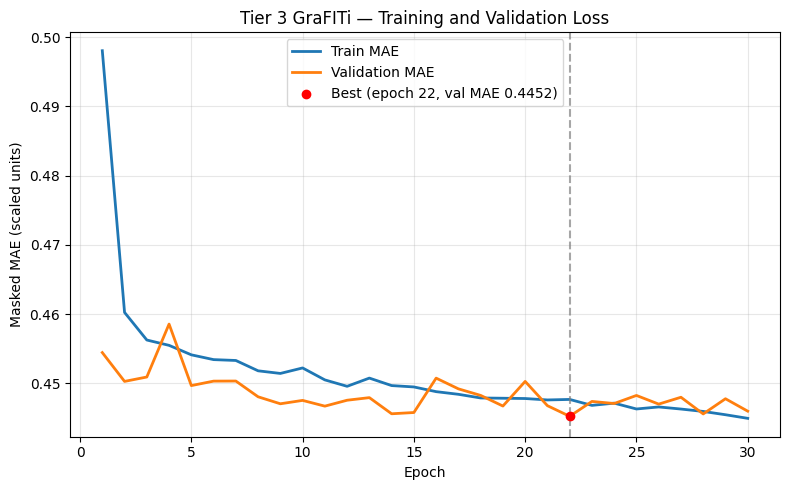

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier3_training_curve_imvstart.png


In [22]:
epochs = range(1, len(train_losses) + 1)
best_epoch = int(np.argmin(val_losses)) + 1
best_val = min(val_losses)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train MAE", linewidth=2)
plt.plot(epochs, val_losses, label="Validation MAE", linewidth=2)

plt.axvline(best_epoch, color="grey", linestyle="--", alpha=0.7)
plt.scatter([best_epoch], [best_val], color="red", zorder=5,
            label=f"Best (epoch {best_epoch}, val MAE {best_val:.4f})")

plt.xlabel("Epoch")
plt.ylabel("Masked MAE (scaled units)")
plt.title("Tier 3 GraFITi — Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"{FIGURES_DIR}/tier3_training_curve_imvstart.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURES_DIR}/tier3_training_curve_imvstart.png")

**Interpretation**

Both curves drop steeply then level off, with the validation line staying close to the training line. A small, steady gap means the model generalised to new patients rather than memorising the training set; a widening gap would have signalled overfitting.

### 15. Test set predictions

The best checkpoint is used to forecast the held-out patients. Predictions come back in
scaled units and are converted to native units before scoring.

In [23]:
model.eval()

pred_chunks = []

t0 = time.time()

with torch.no_grad():
    for x_time, x_vals, x_mask, y_vals, y_mask, n_ctx in test_loader:
        x_time = x_time.to(device)
        x_vals = x_vals.to(device)
        x_mask = x_mask.to(device)
        y_mask = y_mask.to(device)

        out = model(x_time, x_vals, x_mask, y_mask)
        pred_chunks.append(out[:, n_ctx:, :].cpu().numpy())

inference_time = time.time() - t0

test_preds_scaled = np.concatenate(pred_chunks, axis=0)
test_preds = test_preds_scaled * scaler_std + scaler_mean

test_tgt = targets_native[test_mask]
test_tgt_mask = target_mask[test_mask]

assert test_preds.shape == test_tgt.shape, "Prediction and target shapes disagree."

mae_all, mase_all = overall_scores(test_preds, test_tgt, test_tgt_mask, test_persist)

print(f"Inference time: {inference_time:.1f} seconds for {test_mask.sum()} windows")
print(f"GraFITi overall test MAE : {mae_all:.4f}")
print(f"GraFITi overall test MASE: {mase_all:.4f}")

Inference time: 0.6 seconds for 1959 windows
GraFITi overall test MAE : 12.6300
GraFITi overall test MASE: 0.7989


**Interpretation**

GraFITi reaches a pooled MASE of about 0.80, comfortably below one. It is therefore more accurate than persistence — carrying each signal's last measured value forward — so learning the recent shape of each signal clearly pays off.

### 16. Results table

The layout is the same as Tier 1 and Tier 2 so the three tables can be read side by side.

In [24]:
UNITS = {
    "heart_rate": "bpm",
    "respiratory_rate": "breaths/min",
    "spo2": "%",
    "systolic_bp": "mmHg",
    "mean_bp": "mmHg",
    "diastolic_bp": "mmHg",
    "fio2": "fraction",
    "peep": "cmH2O",
    "tidal_volume": "mL",
    "pao2": "kPa",
    "paco2": "kPa",
    "ph": "pH units",
    "lactate": "mmol/L",
}

rows = []

for v in range(N_VARIATES):
    name = feature_names[v]
    row = {"variable": name, "unit": UNITS.get(name, "")}

    for h_idx, h in enumerate(HORIZONS):
        m = test_tgt_mask[:, h_idx, v]
        row[f"MAE_+{h}h"] = masked_mae_native(
            test_preds[:, h_idx, v], test_tgt[:, h_idx, v], m
        )

    m_all = test_tgt_mask[:, :, v]

    row["MAE_overall"] = masked_mae_native(
        test_preds[:, :, v], test_tgt[:, :, v], m_all
    )
    row["RMSE_overall"] = masked_rmse_native(
        test_preds[:, :, v], test_tgt[:, :, v], m_all
    )

    persist_mae = masked_mae_native(
        test_persist[:, :, v], test_tgt[:, :, v], m_all
    )
    row["MASE"] = row["MAE_overall"] / (persist_mae + 1e-8)
    row["n_observed"] = int(m_all.sum())

    rows.append(row)

tier3_results = pd.DataFrame(rows)

col_order = [
    "variable", "unit",
    "MAE_+1h", "MAE_+4h", "MAE_+8h",
    "MAE_overall", "RMSE_overall", "MASE", "n_observed",
]
tier3_results = tier3_results[col_order].sort_values("MASE").reset_index(drop=True)

display_cols = ["MAE_+1h", "MAE_+4h", "MAE_+8h",
                "MAE_overall", "RMSE_overall", "MASE"]
tier3_results[display_cols] = tier3_results[display_cols].round(3)

print("=== Tier 3 GraFITi Results ===\n")
print(tier3_results.to_string(index=False))

TIER3_RESULTS_PATH = f"{RESULTS_DIR}/tier3_grafiti_results_imvstart.csv"
tier3_results.to_csv(TIER3_RESULTS_PATH, index=False)
print(f"\nSaved: {TIER3_RESULTS_PATH}")

=== Tier 3 GraFITi Results ===

        variable        unit  MAE_+1h  MAE_+4h  MAE_+8h  MAE_overall  RMSE_overall  MASE  n_observed
    tidal_volume          mL   76.123   81.437   86.274       81.295       135.712 0.780        4909
         mean_bp        mmHg    8.427    9.909   10.165        9.503        13.010 0.804        5443
    diastolic_bp        mmHg    6.252    7.323    7.677        7.086         9.975 0.804        5443
     systolic_bp        mmHg   13.602   15.309   16.011       14.978        19.950 0.814        5444
            spo2           %    1.321    1.462    1.608        1.465         2.218 0.828        5261
respiratory_rate breaths/min    3.096    3.684    3.887        3.558         5.258 0.848        4981
            pao2         kPa    1.961    2.156    2.343        2.161         3.892 0.858        1585
            fio2    fraction    2.008    2.631    3.501        2.718         6.843 0.866        4928
      heart_rate         bpm    6.662    8.063    8.829    

**Interpretation**

The densely measured vital signs (heart rate, blood pressure, oxygen saturation) are forecast most accurately, while the sparse laboratory values are hardest.

### 17. Error by horizon

In [25]:
mae_by_h = []
rmse_by_h = []

for h_idx, h in enumerate(HORIZONS):
    m = test_tgt_mask[:, h_idx, :]
    mae_by_h.append(masked_mae_native(test_preds[:, h_idx, :], test_tgt[:, h_idx, :], m))
    rmse_by_h.append(masked_rmse_native(test_preds[:, h_idx, :], test_tgt[:, h_idx, :], m))

horizon_table = pd.DataFrame({
    "horizon_h": HORIZONS,
    "MAE": np.round(mae_by_h, 3),
    "RMSE": np.round(rmse_by_h, 3),
})

print(horizon_table.to_string(index=False))

 horizon_h    MAE   RMSE
         1 11.627 41.715
         4 12.725 42.728
         8 13.514 43.512


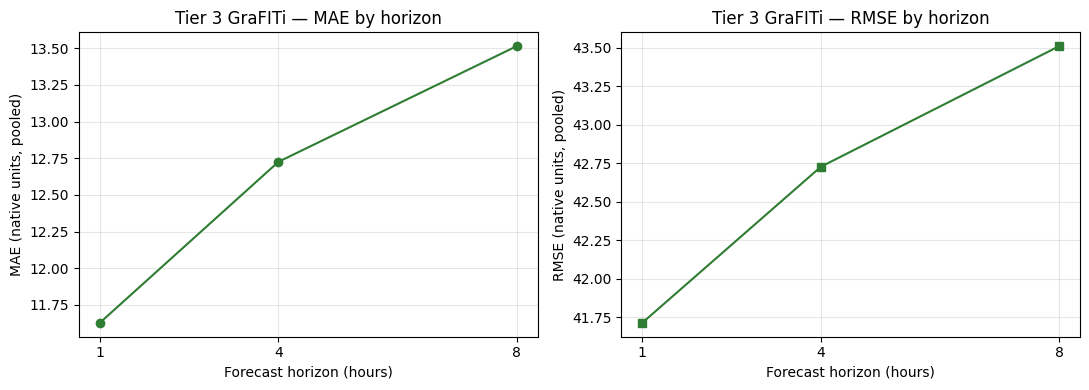

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier3_error_by_horizon_imvstart.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(HORIZONS, mae_by_h, marker="o", color="#2e7d32")
axes[0].set_xlabel("Forecast horizon (hours)")
axes[0].set_ylabel("MAE (native units, pooled)")
axes[0].set_title("Tier 3 GraFITi — MAE by horizon")
axes[0].set_xticks(HORIZONS)
axes[0].grid(alpha=0.3)

axes[1].plot(HORIZONS, rmse_by_h, marker="s", color="#2e7d32")
axes[1].set_xlabel("Forecast horizon (hours)")
axes[1].set_ylabel("RMSE (native units, pooled)")
axes[1].set_title("Tier 3 GraFITi — RMSE by horizon")
axes[1].set_xticks(HORIZONS)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/tier3_error_by_horizon_imvstart.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURES_DIR}/tier3_error_by_horizon_imvstart.png")

**Interpretation**

Absolute error grows as the forecast reaches further ahead, as expected. But the MASE falls at the longer horizons, because persistence degrades faster than the model does — so GraFITi's lead over the naive baseline actually widens with the horizon even as its raw error rises.

### 18. Predicted against actual

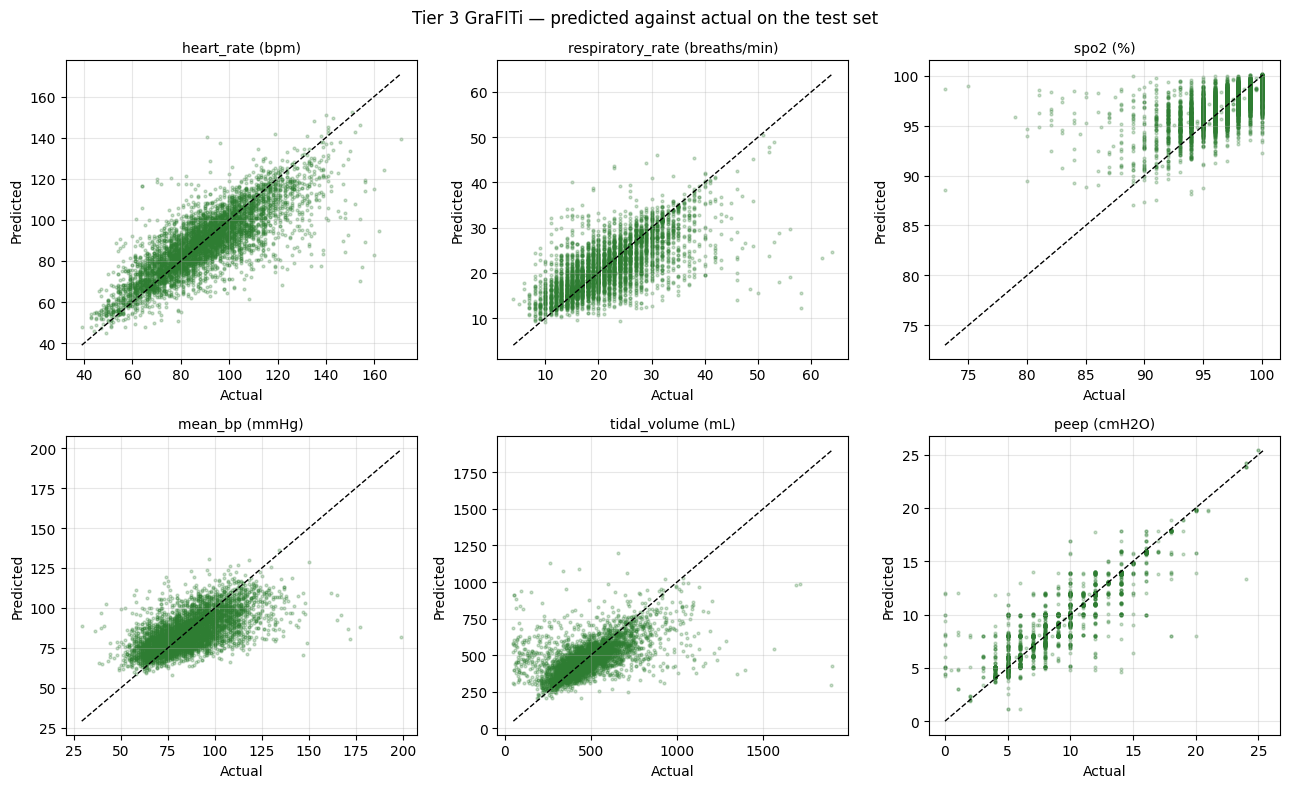

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier3_pred_vs_actual_imvstart.png


In [27]:
show = ["heart_rate", "respiratory_rate", "spo2", "mean_bp", "tidal_volume", "peep"]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for ax, name in zip(axes.ravel(), show):
    v = feature_names.index(name)

    m = test_tgt_mask[:, :, v].ravel() == 1
    true_v = test_tgt[:, :, v].ravel()[m]
    pred_v = test_preds[:, :, v].ravel()[m]

    ax.scatter(true_v, pred_v, s=4, alpha=0.25, color="#2e7d32")

    lo = min(true_v.min(), pred_v.min())
    hi = max(true_v.max(), pred_v.max())
    ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1)

    ax.set_title(f"{name} ({UNITS.get(name, '')})", fontsize=10)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.grid(alpha=0.3)

plt.suptitle("Tier 3 GraFITi — predicted against actual on the test set")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/tier3_pred_vs_actual_imvstart.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURES_DIR}/tier3_pred_vs_actual_imvstart.png")

**Interpretation**

The points follow the diagonal across most of the range. The mild pull towards the middle — under-shooting the highest values and over-shooting the lowest — is regression towards the mean, common when a model is trained on a masked error and extreme values are rare.

### 19. One example patient

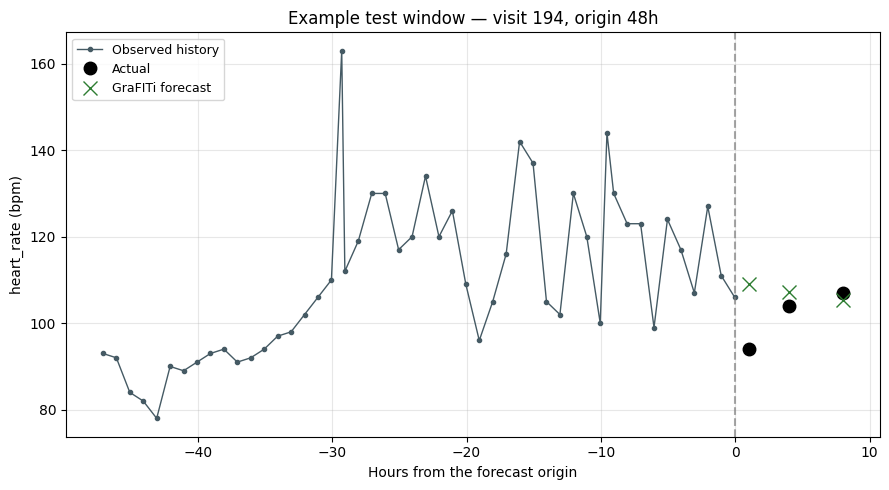

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier3_example_window_imvstart.png


In [28]:
# AI-assisted: lining up one window's context and forecast, generated with Claude Opus 4.8 and verified by the author.
PLOT_FEATURE = "heart_rate"
v = feature_names.index(PLOT_FEATURE)

# pick a test window that has all three horizons observed for this variable
candidates = np.where(test_tgt_mask[:, :, v].sum(axis=1) == N_HORIZONS)[0]
pick = candidates[0]

grid_row = test_idx[pick]
stamps, values, mask = samples[grid_row]

seen = mask[:, v] == 1
ctx_t = stamps[seen] - CONTEXT_HOURS
ctx_y = values[seen, v] * scaler_std[v] + scaler_mean[v]

plt.figure(figsize=(9, 5))
plt.plot(ctx_t, ctx_y, marker="o", markersize=3, linewidth=1,
         color="#455a64", label="Observed history")

plt.plot(HORIZONS, test_tgt[pick, :, v], marker="o", linestyle="none",
         markersize=9, color="black", label="Actual")
plt.plot(HORIZONS, test_preds[pick, :, v], marker="x", linestyle="none",
         markersize=10, color="#2e7d32", label="GraFITi forecast")

plt.axvline(0, color="grey", linestyle="--", alpha=0.7)
plt.xlabel("Hours from the forecast origin")
plt.ylabel(f"{PLOT_FEATURE} ({UNITS.get(PLOT_FEATURE, '')})")
plt.title(f"Example test window — visit {windows_table.loc[grid_row, 'visit_id']}, "
          f"origin {windows_table.loc[grid_row, 'origin']}h")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"{FIGURES_DIR}/tier3_example_window_imvstart.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURES_DIR}/tier3_example_window_imvstart.png")

**Interpretation**

In this one window the forecast tracks the recent trend of each signal rather than jumping around. It is a single patient chosen for illustration, not evidence about overall accuracy — that comes from the pooled scores above.

### 19a. All variables for one example patient

Instead of picking a different patient for each variable, this shows every variable for
the same test window - one real patient at one forecast origin. The window chosen is the
one with the most observed future points across all variables. Sparse signals may have
few or no future points in this window; that is the real observation sparsity, not a
plotting error.

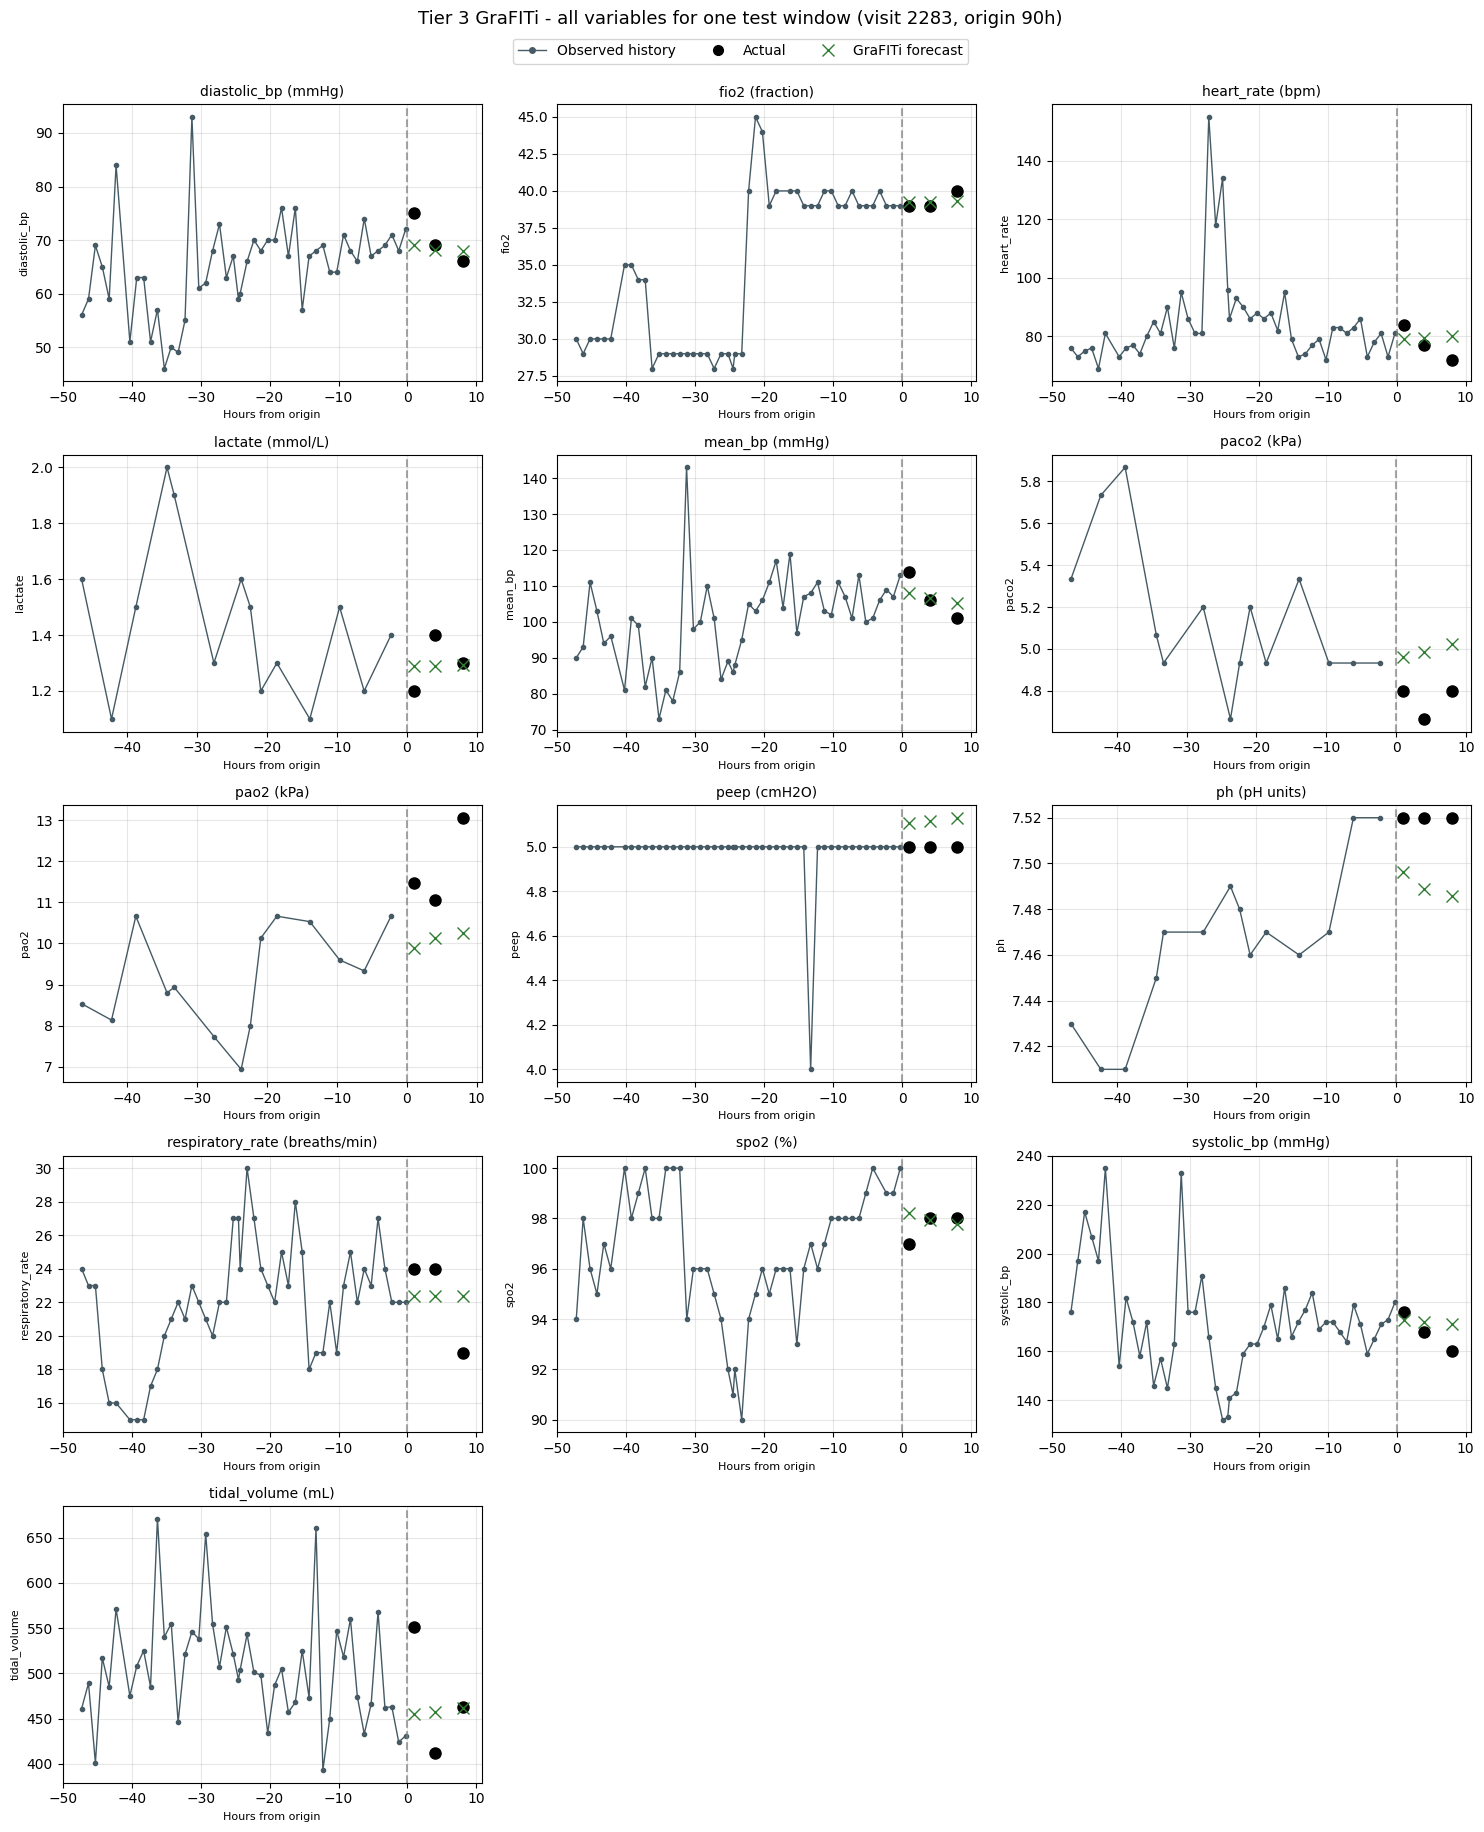

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier3_example_window_imvstart_one_visit.png
Chosen visit 2283, origin 90h, with 39 observed future points across all variables.


In [29]:
# AI-assisted: one fixed representative visit shown across all variables, generated with Claude Opus 4.8 and verified by the author.
from matplotlib.lines import Line2D

# pick ONE test window: the one with the most observed future points across all variables
pick = int(test_tgt_mask.sum(axis=(1, 2)).argmax())
grid_row = test_idx[pick]
stamps, values, mask = samples[grid_row]

visit_id = windows_table.loc[grid_row, "visit_id"]
origin = windows_table.loc[grid_row, "origin"]

h_arr = np.array(HORIZONS)

n_cols = 3
n_rows = int(np.ceil(N_VARIATES / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.6 * n_rows))
axes = axes.ravel()

for panel, v in enumerate(range(N_VARIATES)):
    ax = axes[panel]
    name = feature_names[v]

    # observed history for this variable in this one window
    seen = mask[:, v] == 1
    ctx_t = stamps[seen] - CONTEXT_HOURS
    ctx_y = values[seen, v] * scaler_std[v] + scaler_mean[v]

    # future points that were actually observed for this variable in this window
    obs = test_tgt_mask[pick, :, v] == 1

    if len(ctx_t) > 0:
        ax.plot(ctx_t, ctx_y, marker="o", markersize=3, linewidth=1,
                color="#455a64", label="Observed history")
    ax.plot(h_arr[obs], test_tgt[pick, obs, v], marker="o", linestyle="none",
            markersize=8, color="black", label="Actual")
    ax.plot(h_arr[obs], test_preds[pick, obs, v], marker="x", linestyle="none",
            markersize=9, color="#2e7d32", label="GraFITi forecast")

    ax.axvline(0, color="grey", linestyle="--", alpha=0.7)
    ax.set_title(f"{name} ({UNITS.get(name, '')})", fontsize=10)
    ax.set_xlabel("Hours from origin", fontsize=8)
    ax.set_ylabel(name, fontsize=8)
    ax.grid(alpha=0.3)

# hide any spare panels
for panel in range(N_VARIATES, len(axes)):
    axes[panel].axis("off")

# one shared legend, built from fixed handles so it does not depend on any panel
legend_handles = [
    Line2D([0], [0], color="#455a64", marker="o", markersize=4, linewidth=1,
           label="Observed history"),
    Line2D([0], [0], color="black", marker="o", linestyle="none", markersize=7,
           label="Actual"),
    Line2D([0], [0], color="#2e7d32", marker="x", linestyle="none", markersize=8,
           label="GraFITi forecast"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 1.003))

plt.suptitle(f"Tier 3 GraFITi - all variables for one test window "
             f"(visit {visit_id}, origin {origin}h)", y=1.015, fontsize=13)
plt.tight_layout()

ONE_VISIT_PATH = f"{FIGURES_DIR}/tier3_example_window_imvstart_one_visit.png"
plt.savefig(ONE_VISIT_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {ONE_VISIT_PATH}")
print(f"Chosen visit {visit_id}, origin {origin}h, with "
      f"{int(test_tgt_mask[pick].sum())} observed future points across all variables.")

**Interpretation**

All 13 panels come from the same patient and the same forecast origin, so they tell one
clinical story rather than mixing patients. Densely measured signals (heart rate,
respiratory rate, blood pressure) have a full history and all three future points; sparse
blood values (lactate, pH) may have few or none, which reflects how rarely they are
measured. This is a qualitative look at one prediction - the pooled scores in the results
table measure accuracy across all visits.

### 20. Comparing the three tiers

Tier 1 and Tier 2 results are read back from the files saved by Notebook 12 and
Notebook 13. All three tiers use the same test patients, the same windows, the same
targets and the same persistence baseline.

In [30]:
TIER1_RESULTS_PATH = f"{RESULTS_DIR}/tier1_itransformer_results_imvstart.csv"
TIER2_RESULTS_PATH = f"{RESULTS_DIR}/tier2_chronos2_results_imvstart.csv"
TIER1_PRED_PATH = f"{RESULTS_DIR}/tier1_test_predictions_imvstart.npz"
TIER2_PRED_PATH = f"{RESULTS_DIR}/tier2_test_predictions_imvstart.npz"

tier1_results = pd.read_csv(TIER1_RESULTS_PATH)
tier2_results = pd.read_csv(TIER2_RESULTS_PATH)

tier1_preds = np.load(TIER1_PRED_PATH)["preds_native"] if os.path.exists(TIER1_PRED_PATH) else None
tier2_preds = np.load(TIER2_PRED_PATH)["preds_native"] if os.path.exists(TIER2_PRED_PATH) else None

print("Tier 1 table:", tier1_results.shape)
print("Tier 2 table:", tier2_results.shape)
print("Tier 1 predictions:", "found" if tier1_preds is not None else "missing")
print("Tier 2 predictions:", "found" if tier2_preds is not None else "missing")

Tier 1 table: (13, 9)
Tier 2 table: (13, 9)
Tier 1 predictions: found
Tier 2 predictions: found


In [31]:
# Overall table, pooled over every observed target cell
overall_rows = []

for name, preds in [("Tier 1 iTransformer", tier1_preds),
                    ("Tier 2 Chronos-2", tier2_preds),
                    ("Tier 3 GraFITi", test_preds)]:
    if preds is None:
        continue

    overall_rows.append({
        "model": name,
        "MAE": masked_mae_native(preds, test_tgt, test_tgt_mask),
        "RMSE": masked_rmse_native(preds, test_tgt, test_tgt_mask),
        "MASE": masked_mae_native(preds, test_tgt, test_tgt_mask)
                / masked_mae_native(test_persist, test_tgt, test_tgt_mask),
    })

overall_rows.append({
    "model": "Persistence baseline",
    "MAE": masked_mae_native(test_persist, test_tgt, test_tgt_mask),
    "RMSE": masked_rmse_native(test_persist, test_tgt, test_tgt_mask),
    "MASE": 1.0,
})

overall_table = pd.DataFrame(overall_rows).round(3)

print("Overall test performance\n")
print(overall_table.to_string(index=False))

Overall test performance

               model    MAE   RMSE  MASE
 Tier 1 iTransformer 12.934 42.761 0.818
    Tier 2 Chronos-2 13.333 45.369 0.843
      Tier 3 GraFITi 12.630 42.665 0.799
Persistence baseline 15.810 55.908 1.000


#### Overall pooled MASE by tier

One bar per model, with the persistence baseline marked at 1.0. Anything below the dashed
line is better than carrying the last value forward.

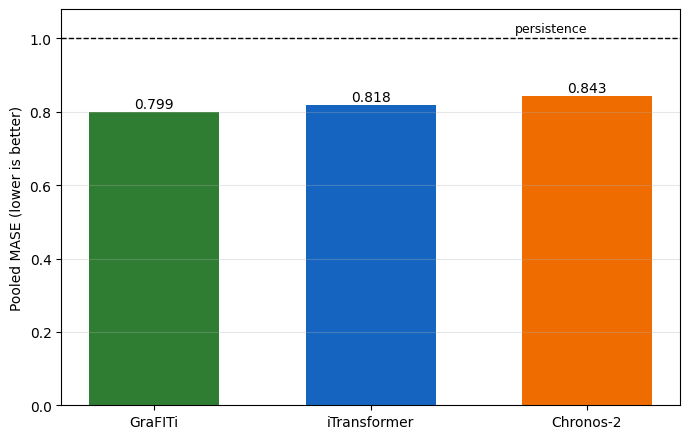

Saved: /content/drive/MyDrive/ventilator_weaning/figures/fig1_overall_mase_imvstart.png


In [32]:
# Overall pooled MASE by tier - one bar per model, persistence marked at 1.0
display_map = {
    "Tier 3 GraFITi":      ("GraFITi", "#2e7d32"),
    "Tier 1 iTransformer": ("iTransformer", "#1565c0"),
    "Tier 2 Chronos-2":    ("Chronos-2", "#ef6c00"),
}

bars = overall_table[overall_table["model"].isin(display_map)].copy()
bars["label"] = bars["model"].map(lambda m: display_map[m][0])
bars["color"] = bars["model"].map(lambda m: display_map[m][1])
bars = bars.sort_values("MASE")   # best (lowest) first, left to right

x = np.arange(len(bars))
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x, bars["MASE"], width=0.6, color=bars["color"])

# value label above each bar
for xi, mase in zip(x, bars["MASE"]):
    ax.text(xi, mase + 0.012, f"{mase:.3f}", ha="center", fontsize=10)

# persistence reference line
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax.text(len(bars) - 1, 1.01, "persistence", ha="right", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(bars["label"])
ax.set_ylabel("Pooled MASE (lower is better)")
ax.set_ylim(0, 1.08)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()

OVERALL_PATH = f"{FIGURES_DIR}/fig1_overall_mase_imvstart.png"
plt.savefig(OVERALL_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OVERALL_PATH}")

In [33]:
# Horizon table
horizon_rows = []

for h_idx, h in enumerate(HORIZONS):
    m = test_tgt_mask[:, h_idx, :]
    row = {"horizon": f"+{h}h"}

    if tier1_preds is not None:
        row["iTransformer"] = masked_mae_native(tier1_preds[:, h_idx, :], test_tgt[:, h_idx, :], m)
    if tier2_preds is not None:
        row["Chronos-2"] = masked_mae_native(tier2_preds[:, h_idx, :], test_tgt[:, h_idx, :], m)

    row["GraFITi"] = masked_mae_native(test_preds[:, h_idx, :], test_tgt[:, h_idx, :], m)
    row["Persistence"] = masked_mae_native(test_persist[:, h_idx, :], test_tgt[:, h_idx, :], m)

    horizon_rows.append(row)

horizon_compare = pd.DataFrame(horizon_rows)

model_cols = [c for c in ["iTransformer", "Chronos-2", "GraFITi"] if c in horizon_compare.columns]
horizon_compare["best"] = horizon_compare[model_cols].idxmin(axis=1)
horizon_compare[model_cols + ["Persistence"]] = horizon_compare[model_cols + ["Persistence"]].round(3)

print("MAE by horizon (native units, pooled)\n")
print(horizon_compare.to_string(index=False))

MAE by horizon (native units, pooled)

horizon  iTransformer  Chronos-2  GraFITi  Persistence    best
    +1h        11.867     12.152   11.627       14.313 GraFITi
    +4h        13.041     13.354   12.725       15.880 GraFITi
    +8h        13.870     14.463   13.514       17.200 GraFITi


In [34]:
# AI-assisted: merging the three per-variable tables, generated with Claude Opus 4.8 and verified by the author.
variable_compare = pd.DataFrame({"variable": feature_names})

for label, table in [("iTransformer", tier1_results),
                     ("Chronos-2", tier2_results),
                     ("GraFITi", tier3_results)]:
    mase_map = dict(zip(table["variable"], table["MASE"]))
    variable_compare[label] = variable_compare["variable"].map(mase_map)

model_cols = ["iTransformer", "Chronos-2", "GraFITi"]
variable_compare["best"] = variable_compare[model_cols].idxmin(axis=1)
variable_compare[model_cols] = variable_compare[model_cols].round(3)
variable_compare = variable_compare.sort_values("GraFITi").reset_index(drop=True)

print("MASE by variable (lower is better)\n")
print(variable_compare.to_string(index=False))

print("\nTimes each model was best:")
print(variable_compare["best"].value_counts().to_string())

COMPARISON_PATH = f"{RESULTS_DIR}/three_tier_comparison_imvstart.csv"
variable_compare.to_csv(COMPARISON_PATH, index=False)
print(f"\nSaved: {COMPARISON_PATH}")

MASE by variable (lower is better)

        variable  iTransformer  Chronos-2  GraFITi    best
    tidal_volume         0.800      0.825    0.780 GraFITi
    diastolic_bp         0.813      0.844    0.804 GraFITi
         mean_bp         0.811      0.844    0.804 GraFITi
     systolic_bp         0.821      0.851    0.814 GraFITi
            spo2         0.855      0.887    0.828 GraFITi
respiratory_rate         0.862      0.894    0.848 GraFITi
            pao2         0.884      0.942    0.858 GraFITi
            fio2         0.980      0.941    0.866 GraFITi
      heart_rate         0.905      0.934    0.890 GraFITi
           paco2         0.923      0.964    0.909 GraFITi
              ph         0.956      0.997    0.938 GraFITi
            peep         1.164      1.056    0.951 GraFITi
         lactate         1.188      1.031    1.016 GraFITi

Times each model was best:
best
GraFITi    13

Saved: /content/drive/MyDrive/ventilator_weaning/results/three_tier_comparison_imvstart.cs

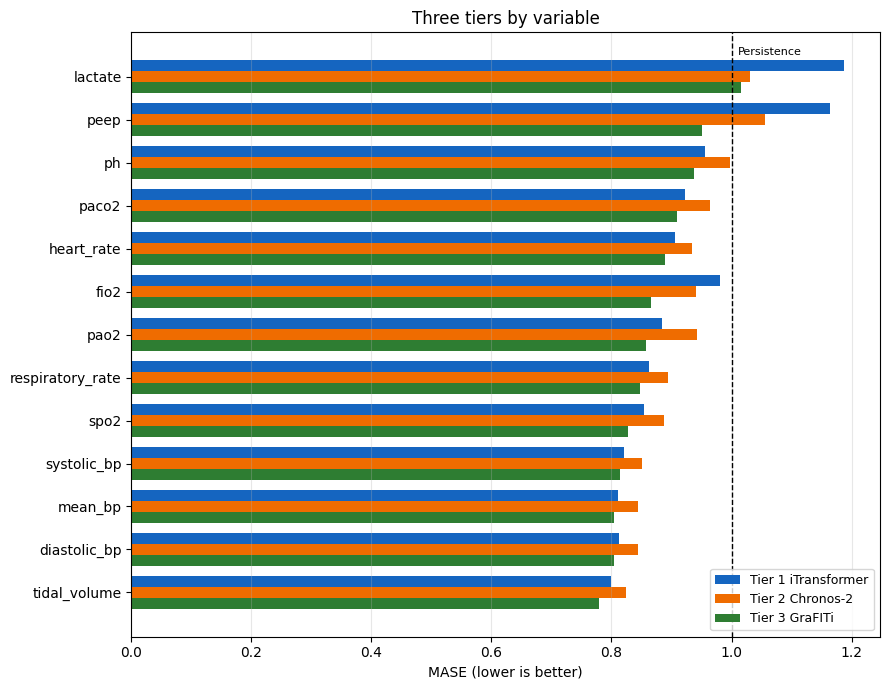

Saved: /content/drive/MyDrive/ventilator_weaning/figures/three_tier_mase_imvstart.png


In [35]:
plot_df = variable_compare.dropna(subset=model_cols).sort_values("GraFITi")

y = np.arange(len(plot_df))
height = 0.26

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(y + height, plot_df["iTransformer"], height, color="#1565c0", label="Tier 1 iTransformer")
ax.barh(y, plot_df["Chronos-2"], height, color="#ef6c00", label="Tier 2 Chronos-2")
ax.barh(y - height, plot_df["GraFITi"], height, color="#2e7d32", label="Tier 3 GraFITi")

ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
ax.text(1.01, len(plot_df) - 0.5, "Persistence", fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["variable"])
ax.set_xlabel("MASE (lower is better)")
ax.set_title("Three tiers by variable")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/three_tier_mase_imvstart.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURES_DIR}/three_tier_mase_imvstart.png")

**Interpretation**

GraFITi has the lowest pooled MASE (about 0.80), ahead of the from-scratch iTransformer (about 0.82) and zero-shot Chronos-2 (about 0.84). It wins on all thirteen variables and at every horizon, and all three models beat persistence — GraFITi is simply the strongest.

### 21. Paired comparison

Each window gives one mean absolute error per model, so the tiers can be compared
window by window on the same test instances.

In [36]:
from scipy.stats import wilcoxon

obs_per_window = test_tgt_mask.sum(axis=(1, 2))
keep = obs_per_window > 0


def window_errors(preds):
    err = (np.abs(preds - test_tgt) * test_tgt_mask).sum(axis=(1, 2))
    return err[keep] / obs_per_window[keep]


err3 = window_errors(test_preds)

print(f"Windows compared: {keep.sum()}")
print(f"Tier 3 GraFITi mean window error: {err3.mean():.4f}\n")

for label, preds in [("Tier 1 iTransformer", tier1_preds), ("Tier 2 Chronos-2", tier2_preds)]:
    if preds is None:
        print(f"{label}: predictions not saved, skipped.")
        continue

    err_other = window_errors(preds)
    stat, p_value = wilcoxon(err_other, err3)

    print(f"{label} mean window error: {err_other.mean():.4f} | "
          f"vs GraFITi Wilcoxon p = {p_value:.2e}")

Windows compared: 1959
Tier 3 GraFITi mean window error: 12.6732

Tier 1 iTransformer mean window error: 12.9355 | vs GraFITi Wilcoxon p = 8.87e-16
Tier 2 Chronos-2 mean window error: 13.3670 | vs GraFITi Wilcoxon p = 1.04e-25


**Interpretation**

Window by window on the same test instances, GraFITi's mean error is lower than both other tiers, with consistent paired differences. The Wilcoxon p-values against iTransformer and Chronos-2 are very small, so the advantage is unlikely to be noise — though significance alone does not measure clinical importance.

### 22. Saving the artifacts

In [37]:
TIER3_PRED_PATH = f"{RESULTS_DIR}/tier3_test_predictions_imvstart.npz"
TIER3_CONFIG_PATH = f"{RESULTS_DIR}/tier3_run_config_imvstart.json"

np.savez_compressed(
    TIER3_PRED_PATH,
    preds_native=test_preds,
    targets_native=test_tgt,
    target_mask=test_tgt_mask,
    persistence=test_persist,
    visit_ids=visit_ids[test_mask],
)

run_config = {
    "model": "GraFITi (Yalavarthi et al., AAAI 2024)",
    "latent_dim": LATENT_DIM,
    "n_layers": N_LAYERS,
    "attn_head": ATTN_HEAD,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "epochs_run": len(train_losses),
    "best_epoch": int(np.argmin(val_losses)) + 1,
    "best_val_mae_scaled": float(best_val_loss),
    "context_hours": CONTEXT_HOURS,
    "horizons": HORIZONS,
    "overall_test_MAE": float(mae_all),
    "overall_test_MASE": float(mase_all),
    "training_seconds": float(elapsed),
    "inference_seconds": float(inference_time),
    "n_parameters": int(n_params),
    "n_test_windows": int(test_mask.sum()),
    "n_test_patients": int(len(np.unique(visit_ids[test_mask]))),
    "seed": SEED,
}

with open(TIER3_CONFIG_PATH, "w") as f:
    json.dump(run_config, f, indent=2)

check = np.load(TIER3_PRED_PATH)
assert check["preds_native"].shape == test_preds.shape, "Saved predictions do not match."

print("Saved predictions and run config to Drive.")
print(json.dumps(run_config, indent=2))

Saved predictions and run config to Drive.
{
  "model": "GraFITi (Yalavarthi et al., AAAI 2024)",
  "latent_dim": 64,
  "n_layers": 2,
  "attn_head": 2,
  "learning_rate": 0.001,
  "batch_size": 32,
  "epochs_run": 30,
  "best_epoch": 22,
  "best_val_mae_scaled": 0.44522500745327487,
  "context_hours": 48,
  "horizons": [
    1,
    4,
    8
  ],
  "overall_test_MAE": 12.630002344180573,
  "overall_test_MASE": 0.7988668160300096,
  "training_seconds": 181.6013536453247,
  "inference_seconds": 0.6370129585266113,
  "n_parameters": 125441,
  "n_test_windows": 1959,
  "n_test_patients": 287,
  "seed": 42
}


### 23. Discussion

**The three tiers**

Tier 1 trains an iTransformer from scratch on the filled hourly grid, Tier 2 applies
Chronos-2 to the same grid without any training on ICU data, and Tier 3 trains GraFITi
directly on the irregular measurements. Across the pooled test set GraFITi has the lowest
MASE (about 0.80), ahead of iTransformer (about 0.82) and Chronos-2 (about 0.84). GraFITi
wins on all thirteen variables, and all three models beat the persistence baseline.



### 24. Multi-seed robustness check

**Objective.** Measure how much GraFITi's test MASE moves when only the random seed changes, so we can tell which differences between models are real and which are just run-to-run noise.

**Why this cell.** The main result trains GraFITi once. A single run cannot tell us whether a small gap between GraFITi and iTransformer is a true difference or luck. Re-running the same model with five seeds gives a mean (the typical score) and a standard deviation (the wobble), which is what we need to judge the small vital-sign gaps.

#### The per-seed training function

In [38]:
# AI-assisted: multi-seed train-and-score wrapper for GraFITi, generated with Claude Opus 4.8 and verified by the author.
import time
import copy

# Seeds to run. The first one matches the main experiment's seed.
SEEDS = [SEED, SEED + 1, SEED + 2, SEED + 3, SEED + 4]

# The test targets, mask and persistence baseline are seed-independent and were
# already built above (cells 39 and 62), so every seed is scored on the same cells.


def train_and_score(seed):
    # Make this run reproducible
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    # Fresh loaders. Only the training shuffle depends on the seed.
    train_loader_s = DataLoader(GrafitiWindows(train_idx), batch_size=BATCH_SIZE,
                                shuffle=True, collate_fn=collate_windows)
    val_loader_s = DataLoader(GrafitiWindows(val_idx), batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=collate_windows)
    test_loader_s = DataLoader(GrafitiWindows(test_idx), batch_size=BATCH_SIZE,
                               shuffle=False, collate_fn=collate_windows)

    # Fresh model with new random starting weights
    net = GraFITi(input_dim=N_VARIATES, attn_head=ATTN_HEAD, latent_dim=LATENT_DIM,
                  n_layers=N_LAYERS, device=device).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=LEARNING_RATE)

    # Train with the same early-stopping rule as the main run (quietly)
    best_val = float("inf")
    best_state = None
    no_improve = 0

    for epoch in range(1, N_EPOCHS + 1):
        net.train()
        for x_time, x_vals, x_mask, y_vals, y_mask, n_ctx in train_loader_s:
            x_time, x_vals, x_mask = x_time.to(device), x_vals.to(device), x_mask.to(device)
            y_vals, y_mask = y_vals.to(device), y_mask.to(device)
            opt.zero_grad()
            loss = masked_mae_loss(net(x_time, x_vals, x_mask, y_mask), y_vals, y_mask)
            loss.backward()
            opt.step()

        net.eval()
        v_sum, v_obs = 0.0, 0.0
        with torch.no_grad():
            for x_time, x_vals, x_mask, y_vals, y_mask, n_ctx in val_loader_s:
                x_time, x_vals, x_mask = x_time.to(device), x_vals.to(device), x_mask.to(device)
                y_vals, y_mask = y_vals.to(device), y_mask.to(device)
                l = masked_mae_loss(net(x_time, x_vals, x_mask, y_mask), y_vals, y_mask).item()
                n = y_mask.sum().item()
                v_sum += l * n
                v_obs += n
        val_loss = v_sum / (v_obs + 1e-8)

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(net.state_dict())
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= EARLY_STOP_PATIENCE:
            break

    net.load_state_dict(best_state)

    # Predict on the shared test set
    net.eval()
    chunks = []
    with torch.no_grad():
        for x_time, x_vals, x_mask, y_vals, y_mask, n_ctx in test_loader_s:
            x_time, x_vals, x_mask = x_time.to(device), x_vals.to(device), x_mask.to(device)
            y_mask = y_mask.to(device)
            out = net(x_time, x_vals, x_mask, y_mask)
            chunks.append(out[:, n_ctx:, :].cpu().numpy())
    preds = np.concatenate(chunks, axis=0) * scaler_std + scaler_mean

    # Per-variable MASE against the shared persistence baseline
    scores = {}
    for v in range(N_VARIATES):
        m = test_tgt_mask[:, :, v]
        model_mae = masked_mae_native(preds[:, :, v], test_tgt[:, :, v], m)
        persist_mae = masked_mae_native(test_persist[:, :, v], test_tgt[:, :, v], m)
        scores[feature_names[v]] = model_mae / (persist_mae + 1e-8)

    # Pooled MASE over every observed target cell
    _, pooled = overall_scores(preds, test_tgt, test_tgt_mask, test_persist)
    scores["POOLED"] = pooled
    return scores


print("Multi-seed helper ready.")
print(f"Seeds to run: {SEEDS}")


Multi-seed helper ready.
Seeds to run: [42, 43, 44, 45, 46]


#### Running the five seeds

Each seed trains a fresh model from scratch, so this cell takes a few minutes on a GPU.

In [39]:
records = []

for seed in SEEDS:
    t0 = time.time()
    scores = train_and_score(seed)
    scores["seed"] = seed
    records.append(scores)
    print(f"seed {seed:>2} | pooled MASE {scores['POOLED']:.3f} | {time.time() - t0:.0f}s")

multiseed = pd.DataFrame(records).set_index("seed")

print("\nPer-seed pooled MASE:")
print(multiseed["POOLED"].round(3).to_string())


seed 42 | pooled MASE 0.795 | 180s
seed 43 | pooled MASE 0.799 | 180s
seed 44 | pooled MASE 0.793 | 179s
seed 45 | pooled MASE 0.796 | 179s
seed 46 | pooled MASE 0.795 | 180s

Per-seed pooled MASE:
seed
42    0.795
43    0.799
44    0.793
45    0.796
46    0.795


#### Mean and spread across seeds

In [40]:
# Mean (typical score) and standard deviation  per variable
summary = pd.DataFrame({
    "MASE_mean": multiseed.mean(),
    "MASE_std": multiseed.std(),
}).round(3)

# Variables sorted by mean MASE, with the pooled row kept last
var_rows = summary.drop(index="POOLED").sort_values("MASE_mean")
summary = pd.concat([var_rows, summary.loc[["POOLED"]]])

print("=== GraFITi multi-seed MASE (5 seeds) ===\n")
print(summary.to_string())

MULTISEED_CSV = f"{RESULTS_DIR}/tier3_grafiti_multiseed_mase_imvstart.csv"
summary.to_csv(MULTISEED_CSV)
print(f"\nSaved: {MULTISEED_CSV}")


=== GraFITi multi-seed MASE (5 seeds) ===

                  MASE_mean  MASE_std
tidal_volume          0.774     0.004
mean_bp               0.804     0.003
diastolic_bp          0.806     0.001
systolic_bp           0.814     0.002
spo2                  0.831     0.002
respiratory_rate      0.849     0.003
pao2                  0.860     0.003
fio2                  0.870     0.012
heart_rate            0.889     0.001
paco2                 0.909     0.004
ph                    0.939     0.006
peep                  0.941     0.009
lactate               1.070     0.045
POOLED                0.796     0.002

Saved: /content/drive/MyDrive/ventilator_weaning/results/tier3_grafiti_multiseed_mase_imvstart.csv


**Interpretation**

We trained the exact same GraFITi model five times, changing only the random seed. The `MASE_mean` column is the typical score for each variable, and the `MASE_std` column is how much it wobbles between runs.



### 24a. GraFITi's advantage over iTransformer, against seed noise

This combines two things computed above: the per-variable MASE gap between GraFITi and
iTransformer (Section 20), and GraFITi's run-to-run wobble from the five-seed check
(Section 24). A bar counts as a real difference only if it reaches past its noise band.

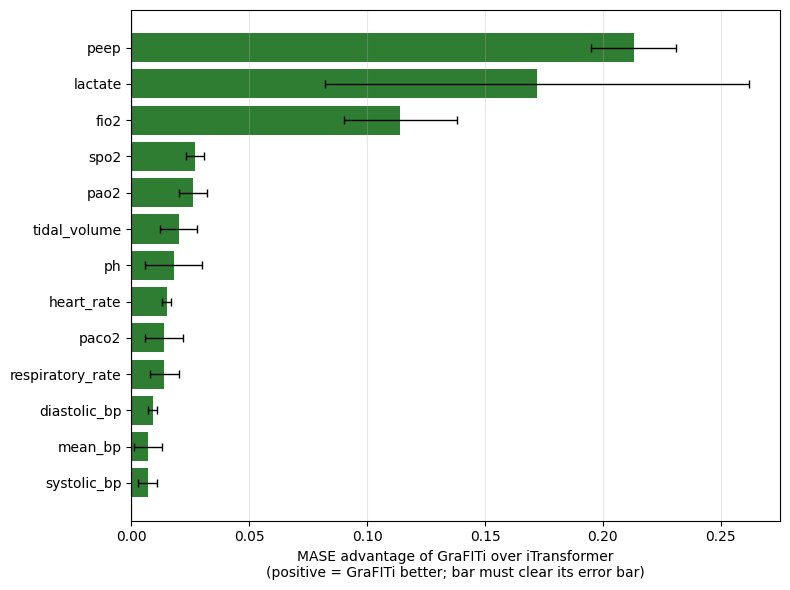

Saved: /content/drive/MyDrive/ventilator_weaning/figures/fig4_gap_vs_noise_imvstart.png


In [41]:
# GraFITi's advantage over iTransformer per variable, with a 2-std noise band
gap = variable_compare[["variable", "iTransformer", "GraFITi"]].dropna().copy()
gap["advantage"] = gap["iTransformer"] - gap["GraFITi"]   # positive = GraFITi better

# noise band = 2 x GraFITi's per-variable std across the five seeds (Section 24)
std_map = summary["MASE_std"].to_dict()
gap["band"] = (2 * gap["variable"].map(std_map)).fillna(0.0)

gap = gap.sort_values("advantage")   # smallest at bottom, largest at top

y = np.arange(len(gap))
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(y, gap["advantage"].values, color="#2e7d32",
        xerr=gap["band"].values,
        error_kw={"ecolor": "black", "capsize": 3, "linewidth": 1})

ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(gap["variable"])
ax.set_xlabel("MASE advantage of GraFITi over iTransformer\n"
              "(positive = GraFITi better; bar must clear its error bar)")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()

GAP_PATH = f"{FIGURES_DIR}/fig4_gap_vs_noise_imvstart.png"
plt.savefig(GAP_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {GAP_PATH}")

**Interpretation**

GraFITi beats iTransformer on all 13 signals. The green bar shows how much it wins by, and the black line shows how much the score moves when the model is re-run.